In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns",None)

In [7]:
df = pd.read_csv("marketing_campaign_cleaned.csv")

df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Year,Month,Month_Name,Quarter,Week,Day,Day_Name,Is_Weekend,CTR,CPC,Engagement_Level,ROI_Level,Campaign_Days
0,1,Innovate Industries,Email,Men 18-24,30 Days,Google Ads,0.04,0.744933,0.715000,Chicago,Spanish,0.451111,0.102444,6.0,Health & Wellness,2021-01-01,2021.0,1.0,January,1.0,53.0,1.0,Friday,False,0.257862,0.138214,Medium,High,30.0
1,2,Nexgen Systems,Email,Women 35-44,60 Days,Google Ads,0.12,0.437733,0.601667,New York,German,0.017778,0.724778,7.0,Fashionistas,2021-01-02,2021.0,1.0,January,1.0,53.0,2.0,Saturday,True,0.005464,0.485720,Medium,Medium,60.0
2,3,Alpha Innovations,Influencer,Men 25-34,30 Days,Youtube,0.07,0.346667,0.863333,Los Angeles,French,0.537778,0.744222,1.0,Outdoor Adventurers,2021-01-03,2021.0,1.0,January,1.0,53.0,3.0,Sunday,True,0.067018,0.063839,Low,High,30.0
3,4,Datatech Solutions,Display,All Ages,60 Days,Youtube,0.11,0.514933,0.591667,Miami,Mandarin,0.130000,0.091111,7.0,Health & Wellness,2021-01-04,2021.0,1.0,January,1.0,1.0,4.0,Monday,False,0.111181,0.275034,Medium,Medium,60.0
4,5,Nexgen Systems,Email,Men 25-34,15 Days,Youtube,0.05,0.763467,0.750000,Los Angeles,Mandarin,0.310000,0.355667,3.0,Health & Wellness,2021-01-05,2021.0,1.0,January,1.0,1.0,5.0,Tuesday,False,0.081634,0.196923,Low,High,NaN


In [8]:
print(df.shape)

df.sample(5)

(27307, 29)


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Year,Month,Month_Name,Quarter,Week,Day,Day_Name,Is_Weekend,CTR,CPC,Engagement_Level,ROI_Level,Campaign_Days
19507,19508,Innovate Industries,Social Media,Men 18-24,45 Days,Email,0.04,0.648400,0.336667,Miami,Spanish,0.843333,0.678111,9.0,Outdoor Adventurers,2021-06-12,2021.0,6.0,June,2.0,23.0,12.0,Saturday,True,0.112916,0.062184,High,Medium,NaN
25470,25471,Nexgen Systems,Social Media,Men 18-24,15 Days,Youtube,0.02,0.834933,0.075000,Houston,Spanish,0.500000,0.241667,10.0,Fashionistas,2021-10-13,2021.0,10.0,October,4.0,41.0,13.0,Wednesday,False,0.166170,0.137688,High,Low,NaN
19555,19556,Nexgen Systems,Influencer,All Ages,60 Days,Google Ads,0.11,0.192600,0.186667,Houston,German,0.300000,0.996000,2.0,Tech Enthusiasts,2021-07-30,2021.0,7.0,July,3.0,30.0,30.0,Friday,False,0.027577,0.083619,Low,Medium,60.0
9390,9391,Datatech Solutions,Display,Women 35-44,60 Days,Email,0.15,0.917333,0.733333,Miami,French,0.851111,0.940778,10.0,Fashionistas,2021-09-23,2021.0,9.0,September,3.0,38.0,23.0,Thursday,False,0.082916,0.085369,High,High,60.0
2954,2955,Innovate Industries,Influencer,Women 35-44,45 Days,Youtube,0.02,0.457333,0.811667,Houston,Spanish,0.057778,0.336667,3.0,Outdoor Adventurers,2021-02-04,2021.0,2.0,February,1.0,5.0,4.0,Thursday,False,0.028171,0.374503,Low,High,NaN


# Numerical Feature Distribution

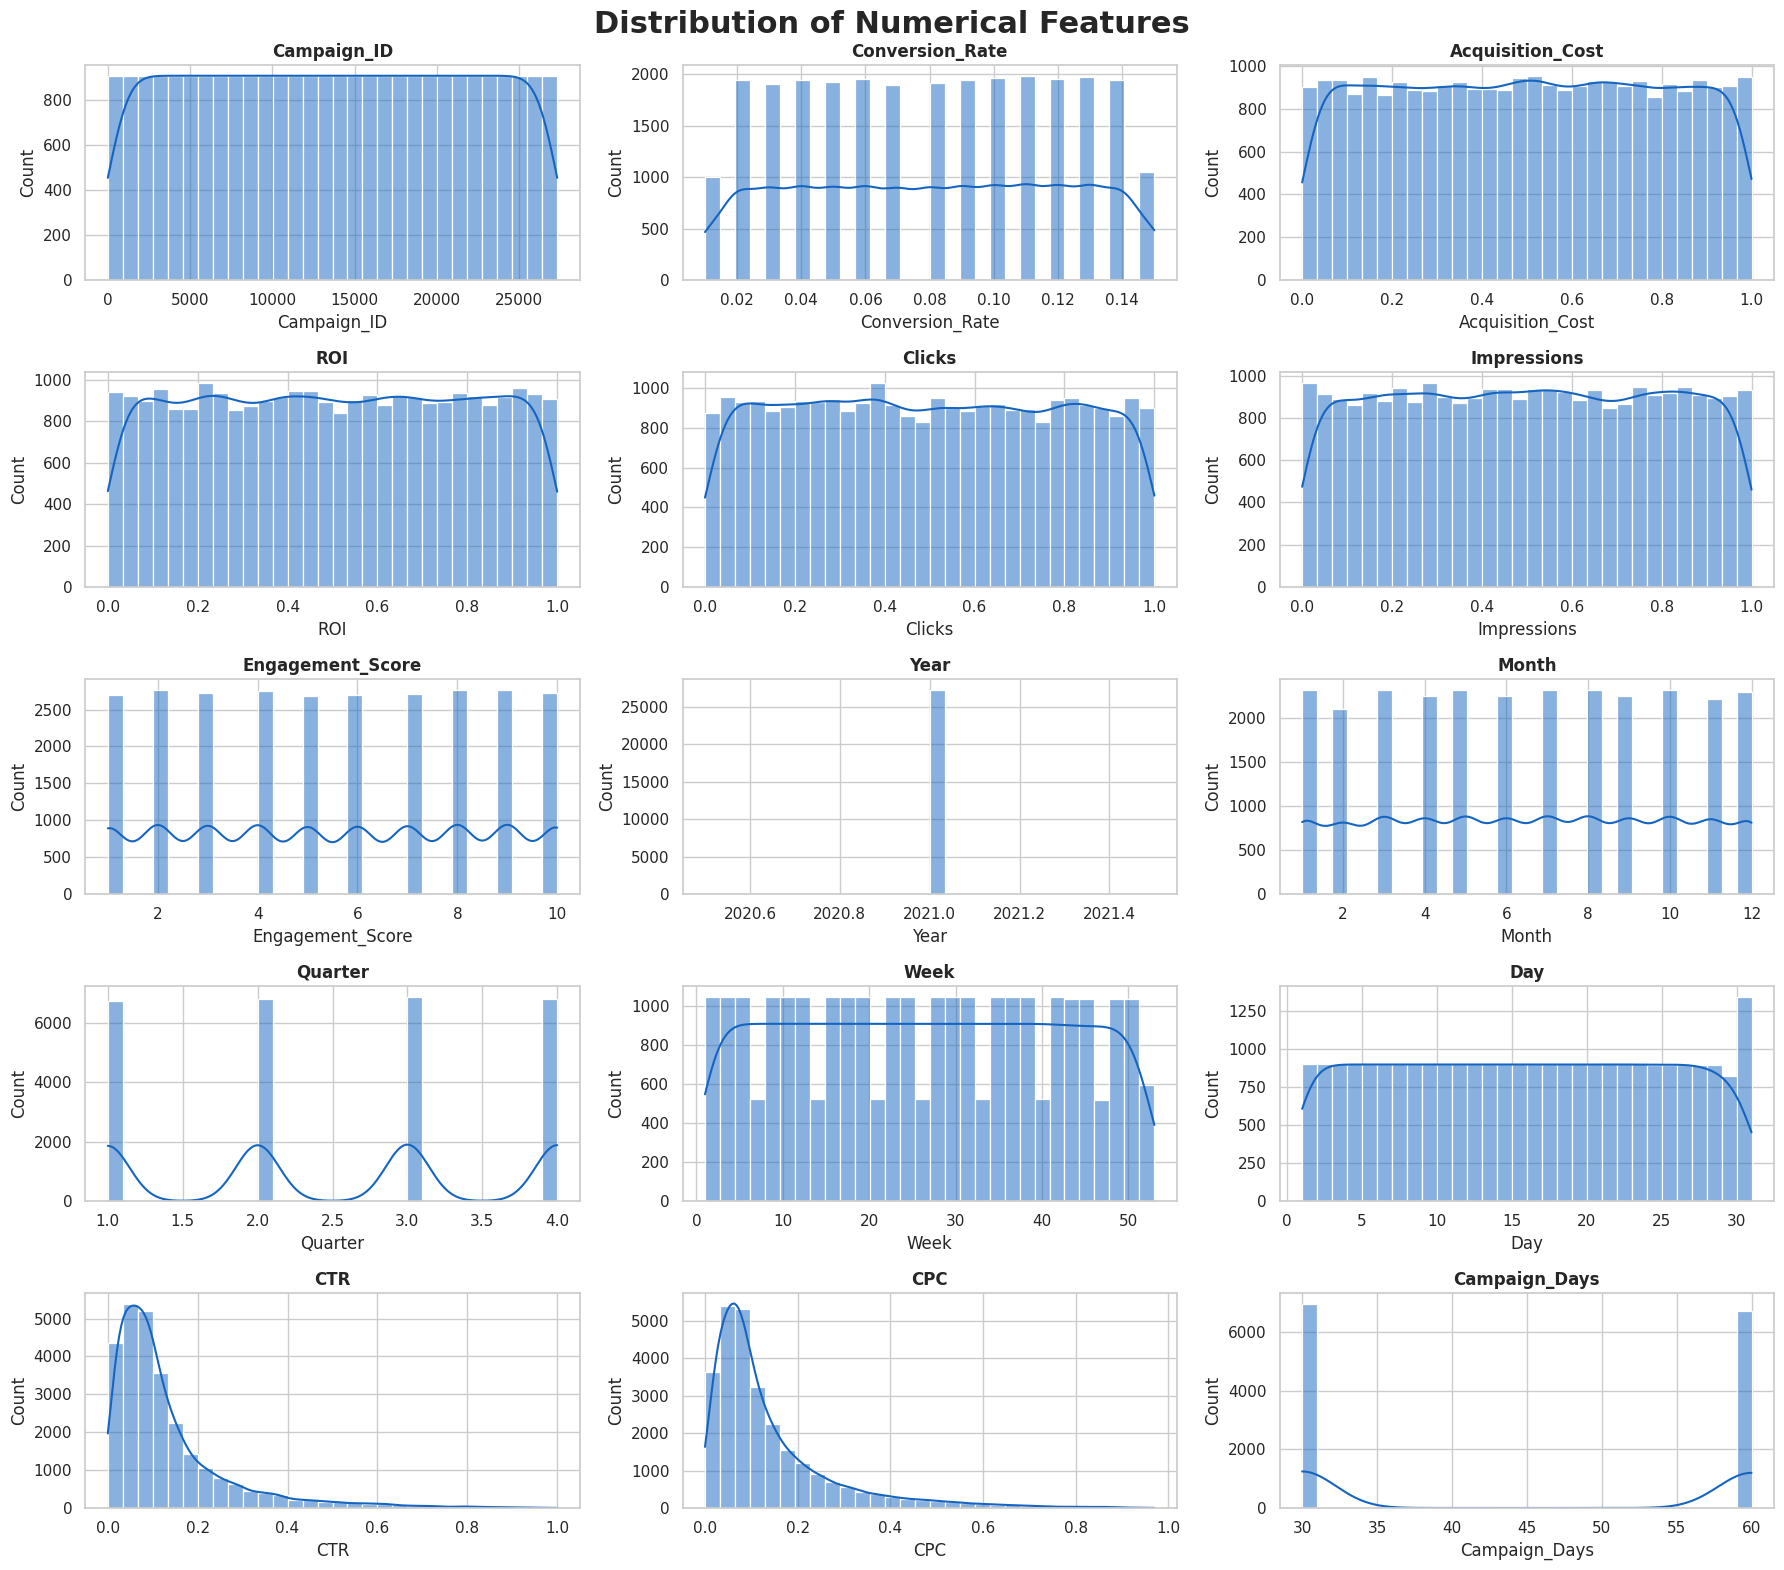

In [9]:
numeric_cols = df.select_dtypes(include=np.number).columns

fig, axes = plt.subplots(
    nrows=((len(numeric_cols)+2)//3),
    ncols=3,
    figsize=(18,16)
)

axes = axes.flatten()

for i,col in enumerate(numeric_cols):

    sns.histplot(
        df[col],
        kde=True,
        bins=30,
        color="#1565C0",
        ax=axes[i]
    )

    axes[i].set_title(col,
                      fontsize=12,
                      fontweight="bold")

for j in range(i+1,len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# Categorical Dashboard

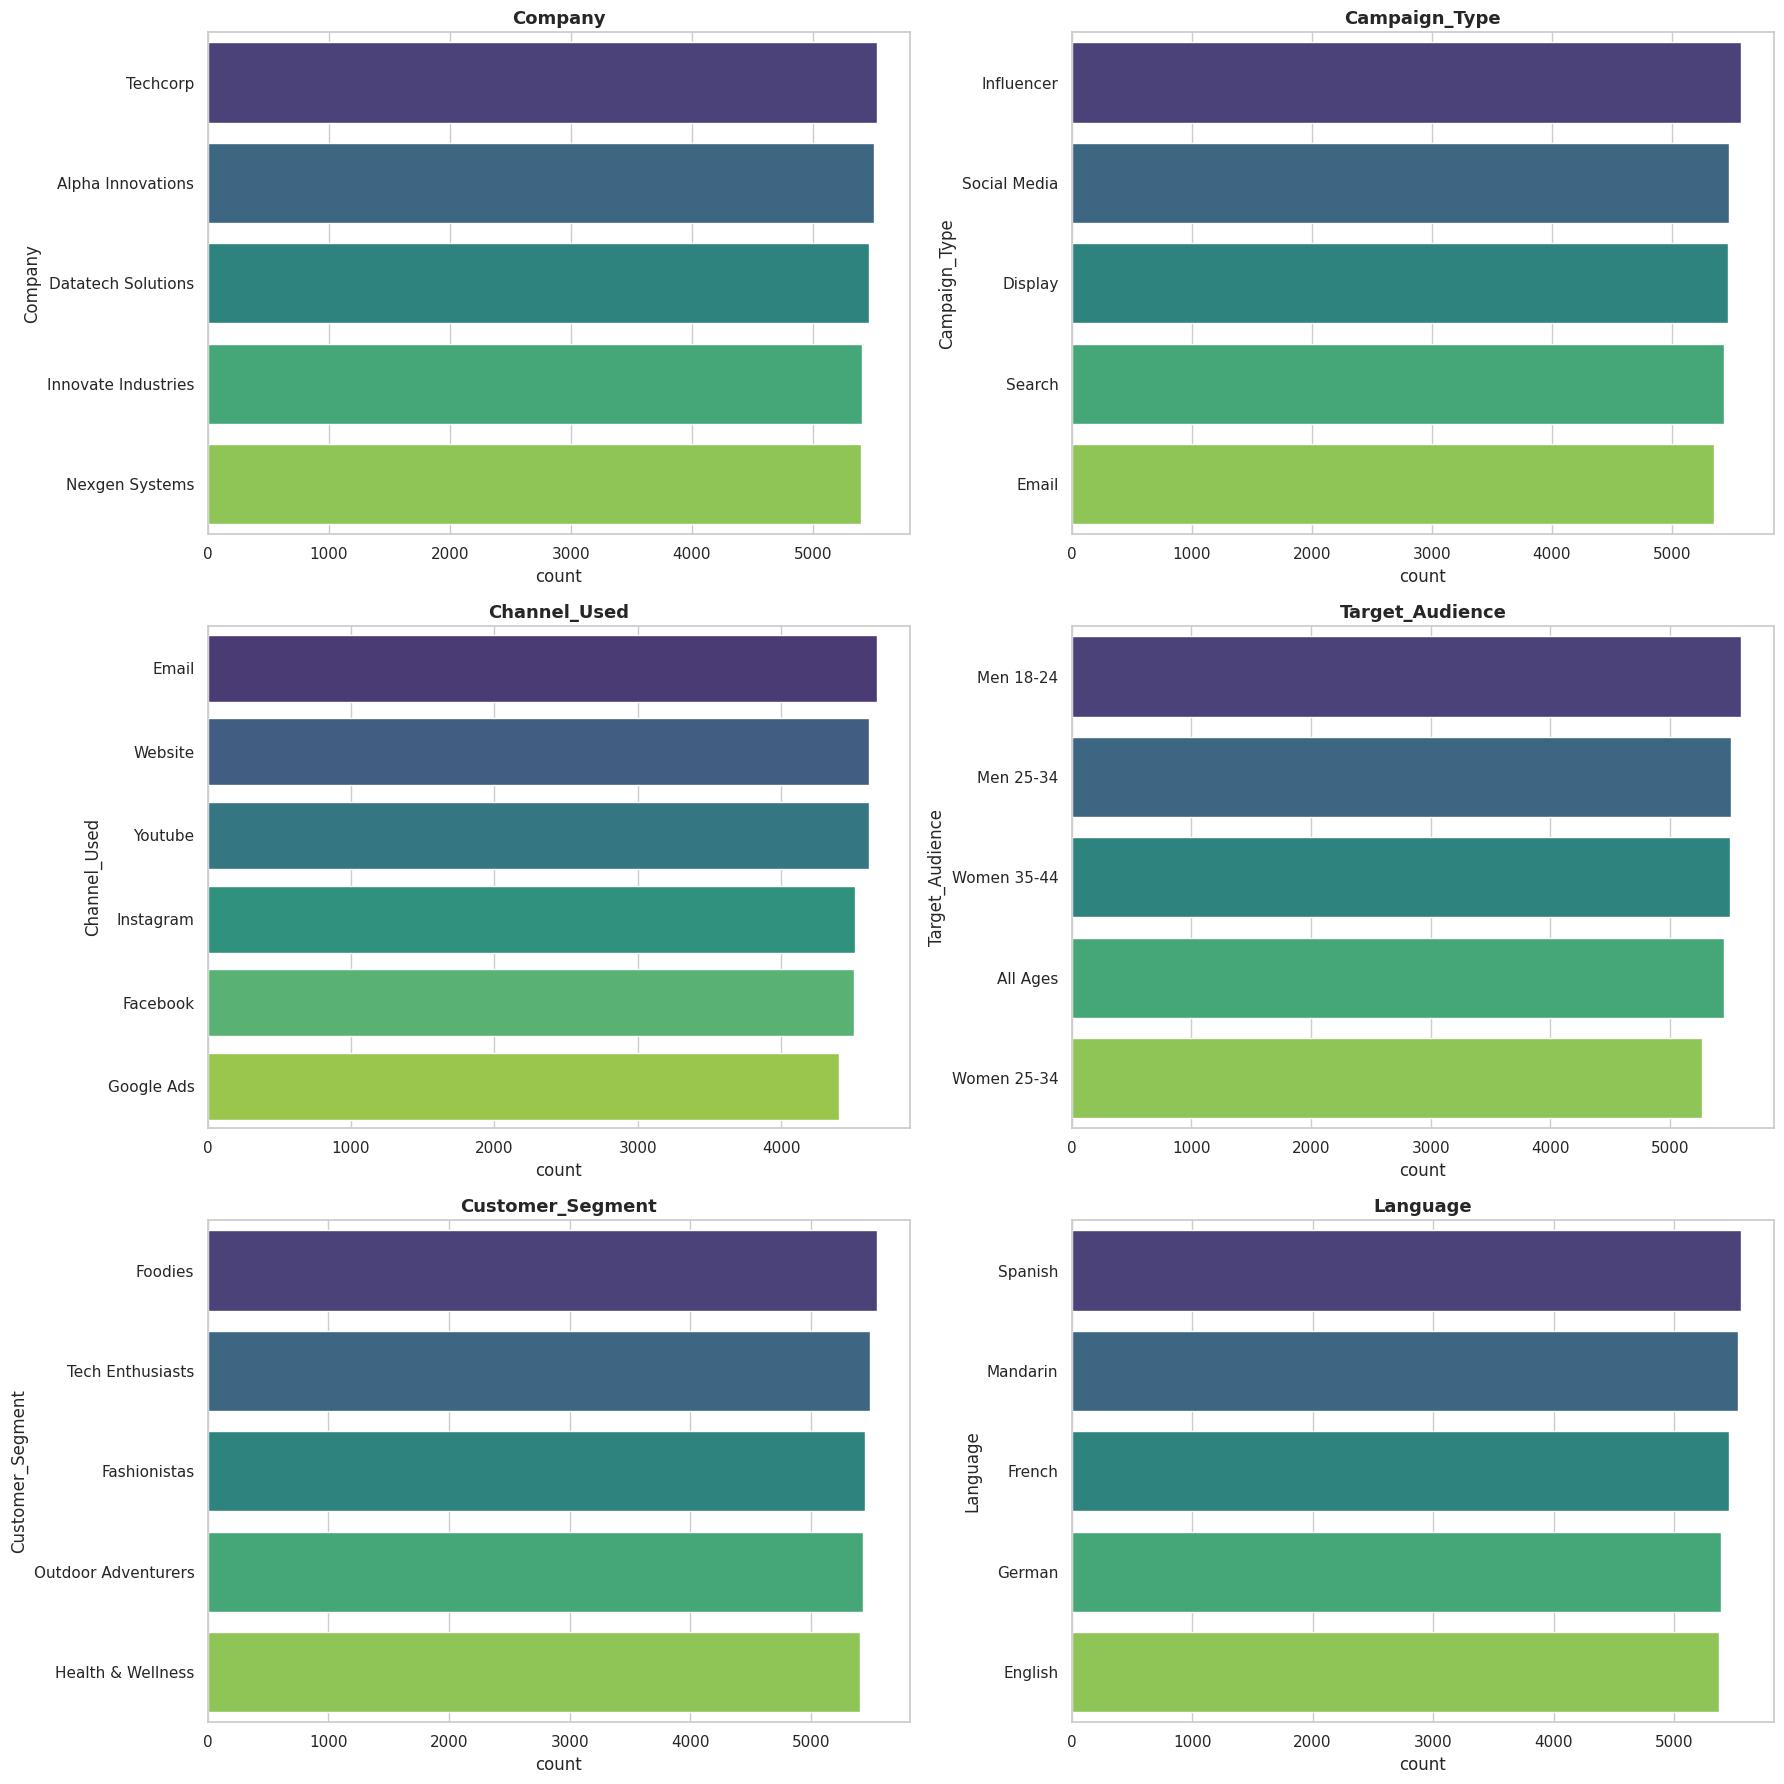

In [10]:
cat_cols = [
    "Company",
    "Campaign_Type",
    "Channel_Used",
    "Target_Audience",
    "Customer_Segment",
    "Language"
]

fig, axes = plt.subplots(3,2,figsize=(18,18))

axes = axes.flatten()

for ax,col in zip(axes,cat_cols):

    order = df[col].value_counts().index

    sns.countplot(
        data=df,
        y=col,
        order=order,
        palette="viridis",
        ax=ax
    )

    ax.set_title(col,
                 fontsize=13,
                 fontweight="bold")

plt.tight_layout()

plt.show()

# Campaign Type Analysis

# Campaign Distribution

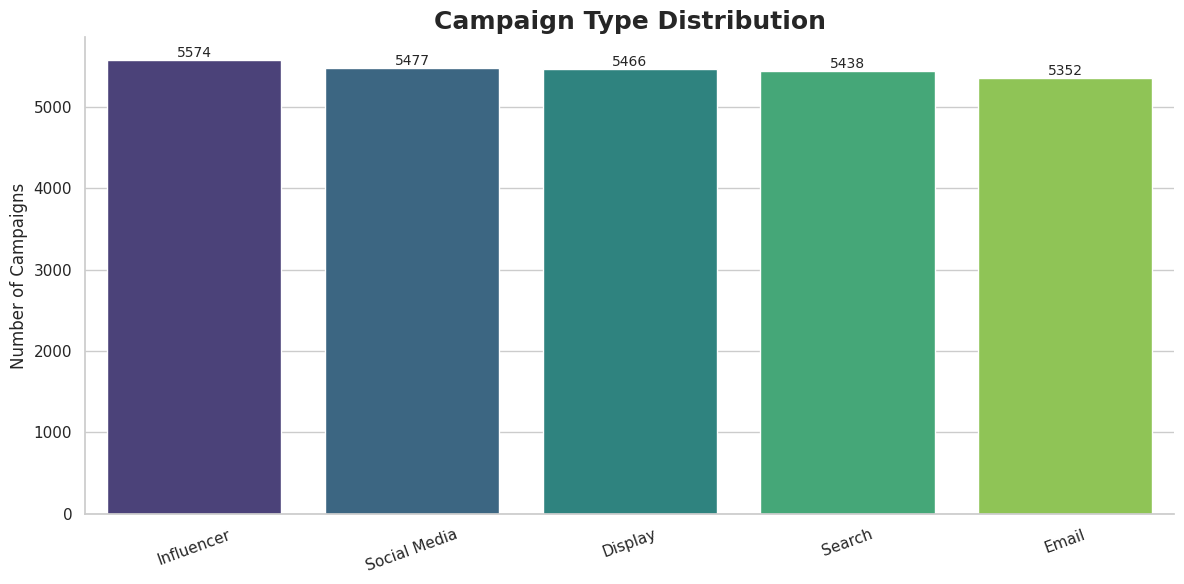

In [11]:
campaign_count = (
    df["Campaign_Type"]
    .value_counts()
    .reset_index()
)

campaign_count.columns = ["Campaign Type", "Count"]

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=campaign_count,
    x="Campaign Type",
    y="Count",
    palette="viridis"
)

plt.title(
    "Campaign Type Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Number of Campaigns")

plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container, fontsize=10)

sns.despine()

plt.tight_layout()
plt.show()

# Average ROI by Campaign Type

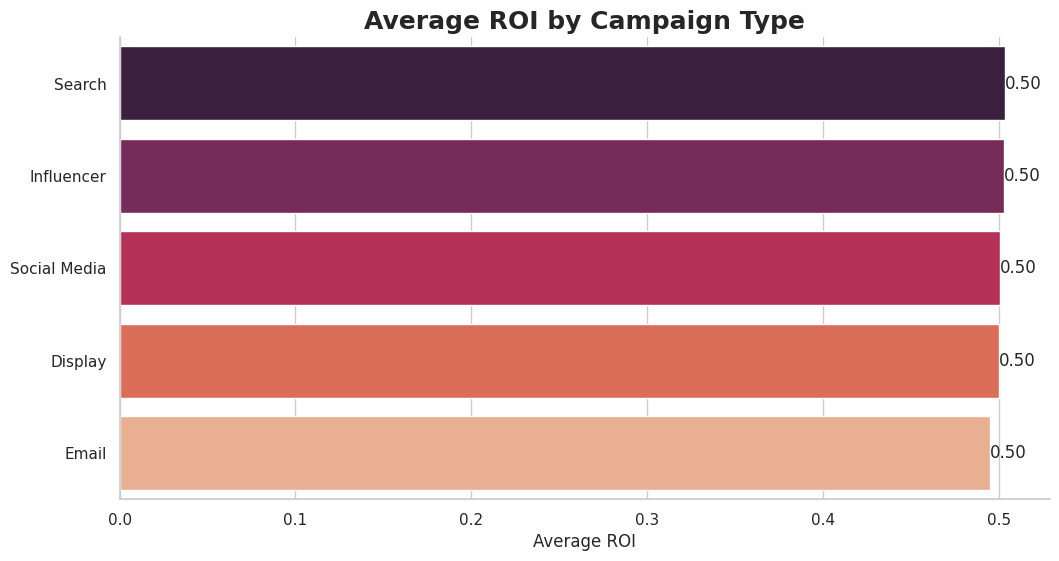

In [12]:
campaign_roi = (
    df.groupby("Campaign_Type")["ROI"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=campaign_roi,
    x="ROI",
    y="Campaign_Type",
    palette="rocket"
)

plt.title(
    "Average ROI by Campaign Type",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Average ROI")
plt.ylabel("")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

sns.despine()

plt.show()

# Campaign KPI Dashboard

In [13]:
campaign_summary = (

df.groupby("Campaign_Type")

.agg({

"ROI":"mean",

"CTR":"mean",

"Clicks":"mean",

"Conversion_Rate":"mean",

"Engagement_Score":"mean"

})

.round(2)

)

campaign_summary

,ROI,CTR,Clicks,Conversion_Rate,Engagement_Score
Campaign_Type,,,,,
Display,0.5,0.14,0.50,0.08,5.48
Email,0.5,0.13,0.49,0.08,5.55
Influencer,0.5,0.13,0.50,0.08,5.50
Search,0.5,0.13,0.49,0.08,5.51
Social Media,0.5,0.13,0.50,0.08,5.50


# Professional KPI Heatmap

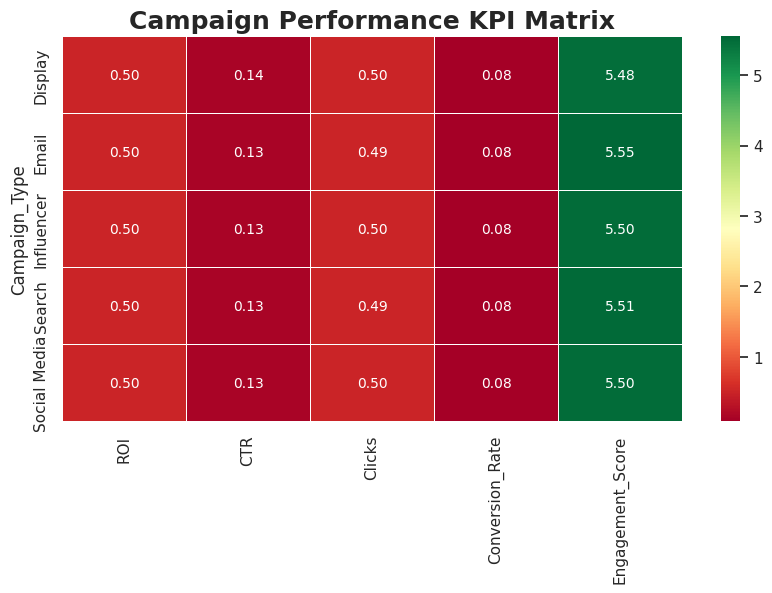

In [14]:
plt.figure(figsize=(10,5))

sns.heatmap(

campaign_summary,

annot=True,

fmt=".2f",

linewidths=.5,

cmap="RdYlGn",

annot_kws={"size":10}

)

plt.title(

"Campaign Performance KPI Matrix",

fontsize=18,

fontweight="bold"

)

plt.show()

# ROI Distribution

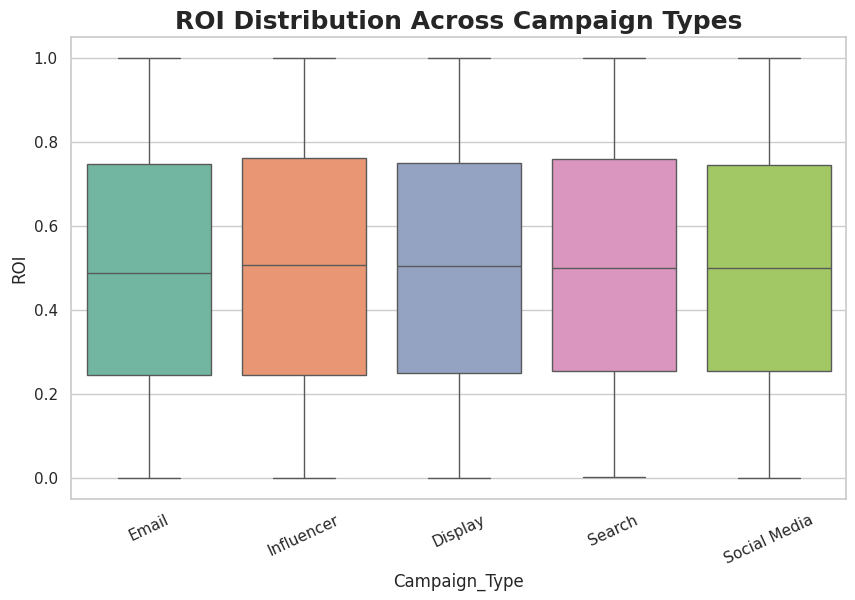

In [15]:
plt.figure(figsize=(10,6))

sns.boxplot(

data=df,

x="Campaign_Type",

y="ROI",

palette="Set2"

)

plt.xticks(rotation=25)

plt.title(

"ROI Distribution Across Campaign Types",

fontsize=18,

fontweight="bold"

)

plt.show()

# Engagement Distribution

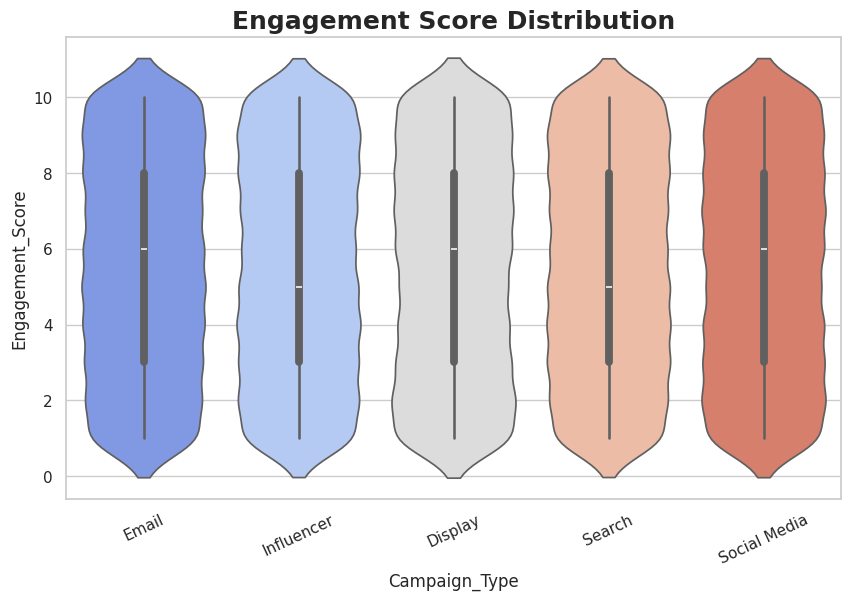

In [16]:
plt.figure(figsize=(10,6))

sns.violinplot(

data=df,

x="Campaign_Type",

y="Engagement_Score",

palette="coolwarm"

)

plt.xticks(rotation=25)

plt.title(

"Engagement Score Distribution",

fontsize=18,

fontweight="bold"

)

plt.show()

# Marketing Channel Analysis

# Channel Distribution

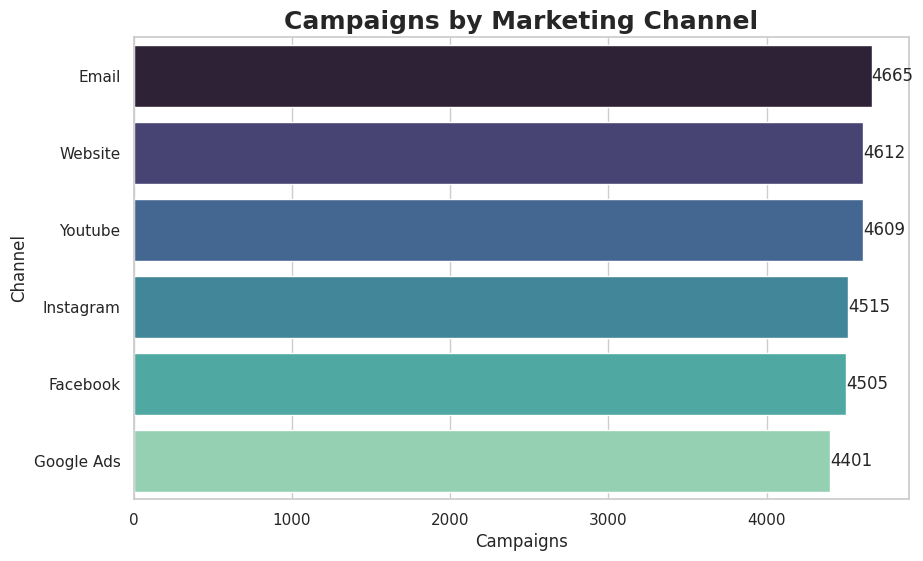

In [17]:
channel_count = (

df["Channel_Used"]

.value_counts()

.reset_index()

)

channel_count.columns=["Channel","Campaigns"]

plt.figure(figsize=(10,6))

ax=sns.barplot(

data=channel_count,

x="Campaigns",

y="Channel",

palette="mako"

)

plt.title(

"Campaigns by Marketing Channel",

fontsize=18,

fontweight="bold"

)

for container in ax.containers:

    ax.bar_label(container)

plt.show()

# Channel KPI Summary

In [18]:
channel_summary = (

df.groupby("Channel_Used")

.agg({

"ROI":"mean",

"CTR":"mean",

"Clicks":"mean",

"Conversion_Rate":"mean",

"Engagement_Score":"mean"

})

.round(2)

)

channel_summary

,ROI,CTR,Clicks,Conversion_Rate,Engagement_Score
Channel_Used,,,,,
Email,0.50,0.13,0.49,0.08,5.52
Facebook,0.50,0.13,0.50,0.08,5.50
Google Ads,0.50,0.13,0.50,0.08,5.50
Instagram,0.49,0.13,0.50,0.08,5.55
Website,0.50,0.13,0.50,0.08,5.50
Youtube,0.50,0.13,0.50,0.08,5.48


# Channel KPI Heatmap

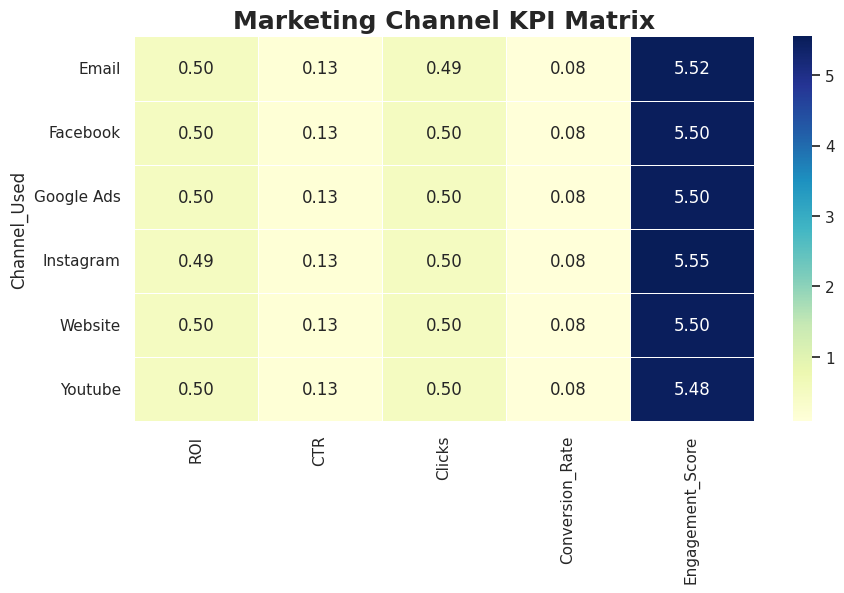

In [19]:
plt.figure(figsize=(10,5))

sns.heatmap(

channel_summary,

annot=True,

fmt=".2f",

linewidth=.5,

cmap="YlGnBu"

)

plt.title(

"Marketing Channel KPI Matrix",

fontsize=18,

fontweight="bold"

)

plt.show()

# Average ROI by Channel

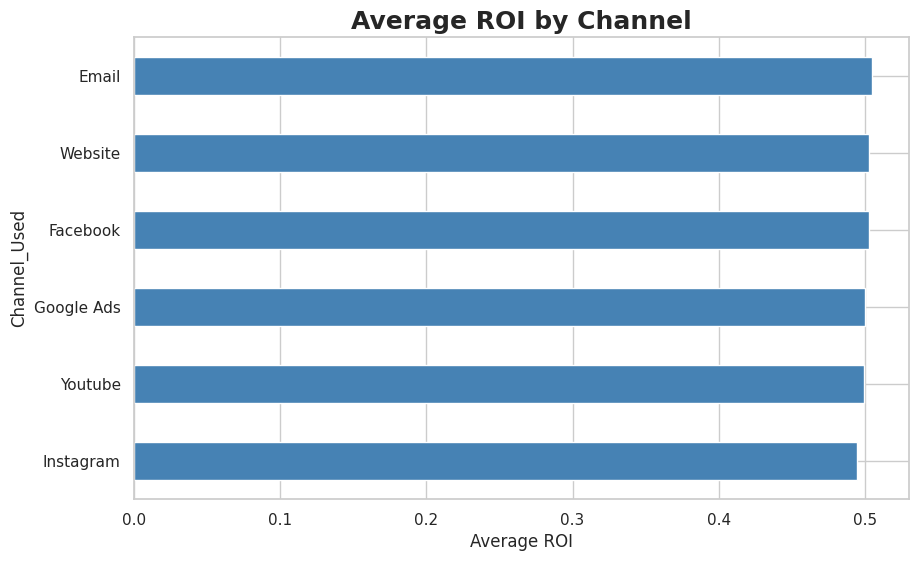

In [20]:
channel_roi = (

df.groupby("Channel_Used")["ROI"]

.mean()

.sort_values()

)

plt.figure(figsize=(10,6))

channel_roi.plot(

kind="barh",

color="steelblue"

)

plt.title(

"Average ROI by Channel",

fontsize=18,

fontweight="bold"

)

plt.xlabel("Average ROI")

plt.show()

# Channel Ranking

In [22]:
channel_rank = (

channel_summary

.sort_values(

by="ROI",

ascending=False

)

)

display(channel_rank.style.background_gradient(cmap="Greens"))

,ROI,CTR,Clicks,Conversion_Rate,Engagement_Score
Channel_Used,,,,,
Email,0.500000,0.130000,0.490000,0.080000,5.520000
Facebook,0.500000,0.130000,0.500000,0.080000,5.500000
Google Ads,0.500000,0.130000,0.500000,0.080000,5.500000
Website,0.500000,0.130000,0.500000,0.080000,5.500000
Youtube,0.500000,0.130000,0.500000,0.080000,5.480000
Instagram,0.490000,0.130000,0.500000,0.080000,5.550000


# Company Performance Analysis

# Company KPI Summary

In [23]:
company_summary = (
    df.groupby("Company")
      .agg(
          Average_ROI=("ROI","mean"),
          Average_CTR=("CTR","mean"),
          Average_Clicks=("Clicks","mean"),
          Average_Conversion=("Conversion_Rate","mean"),
          Average_Engagement=("Engagement_Score","mean")
      )
      .round(2)
      .sort_values("Average_ROI", ascending=False)
)

company_summary

,Average_ROI,Average_CTR,Average_Clicks,Average_Conversion,Average_Engagement
Company,,,,,
Alpha Innovations,0.51,0.13,0.50,0.08,5.52
Datatech Solutions,0.50,0.13,0.49,0.08,5.52
Innovate Industries,0.50,0.13,0.50,0.08,5.53
Techcorp,0.50,0.13,0.50,0.08,5.44
Nexgen Systems,0.49,0.13,0.50,0.08,5.52


# Top Companies by ROI

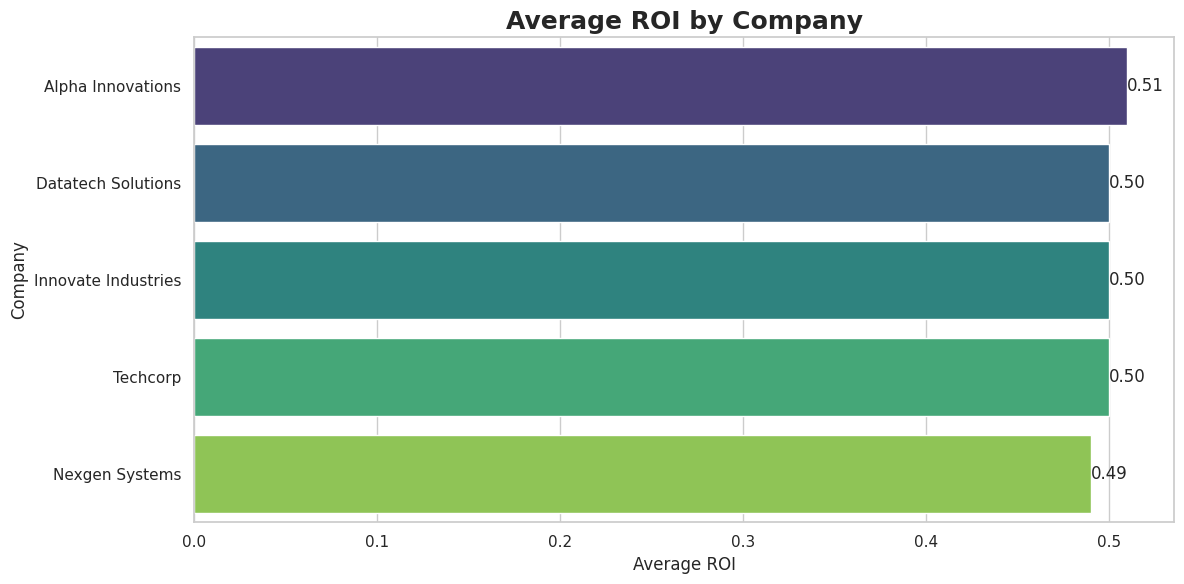

In [24]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=company_summary.reset_index(),
    x="Average_ROI",
    y="Company",
    palette="viridis"
)

plt.title(
    "Average ROI by Company",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Average ROI")
plt.ylabel("Company")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

# Company KPI Heatmap

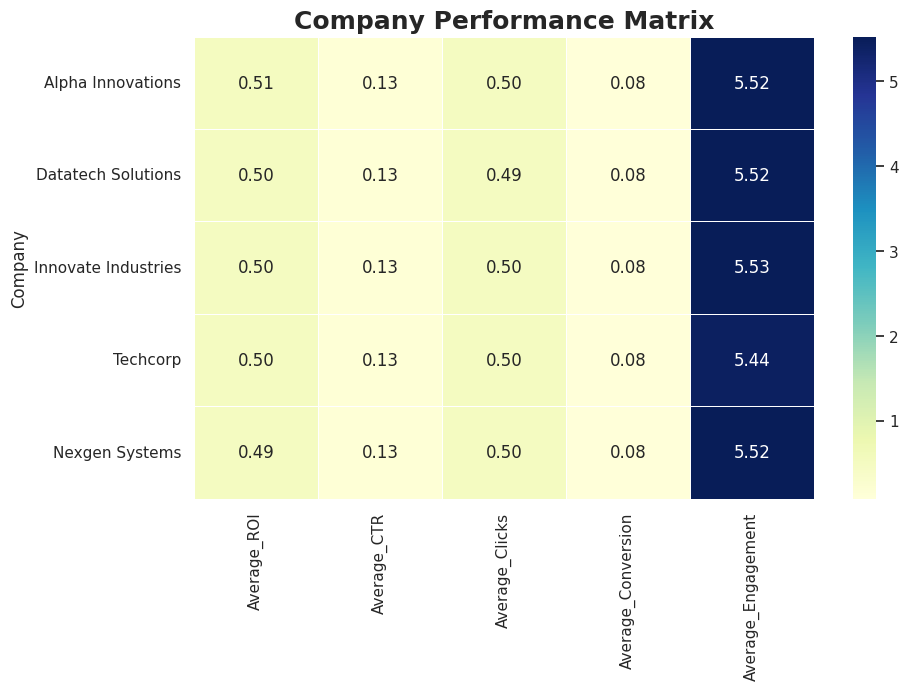

In [25]:
plt.figure(figsize=(10,6))

sns.heatmap(
    company_summary,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=.5
)

plt.title(
    "Company Performance Matrix",
    fontsize=18,
    fontweight="bold"
)

plt.show()

# Target Audience Analysis

# Audience KPI Summary

In [26]:
audience_summary = (
    df.groupby("Target_Audience")
      .agg(
          Average_ROI=("ROI","mean"),
          Average_CTR=("CTR","mean"),
          Average_Clicks=("Clicks","mean"),
          Average_Conversion=("Conversion_Rate","mean"),
          Average_Engagement=("Engagement_Score","mean")
      )
      .round(2)
      .sort_values("Average_ROI", ascending=False)
)

audience_summary

,Average_ROI,Average_CTR,Average_Clicks,Average_Conversion,Average_Engagement
Target_Audience,,,,,
Men 25-34,0.51,0.13,0.5,0.08,5.51
All Ages,0.50,0.13,0.5,0.08,5.46
Men 18-24,0.50,0.13,0.5,0.08,5.51
Women 25-34,0.50,0.13,0.5,0.08,5.57
Women 35-44,0.50,0.13,0.5,0.08,5.49


# ROI by Target Audience

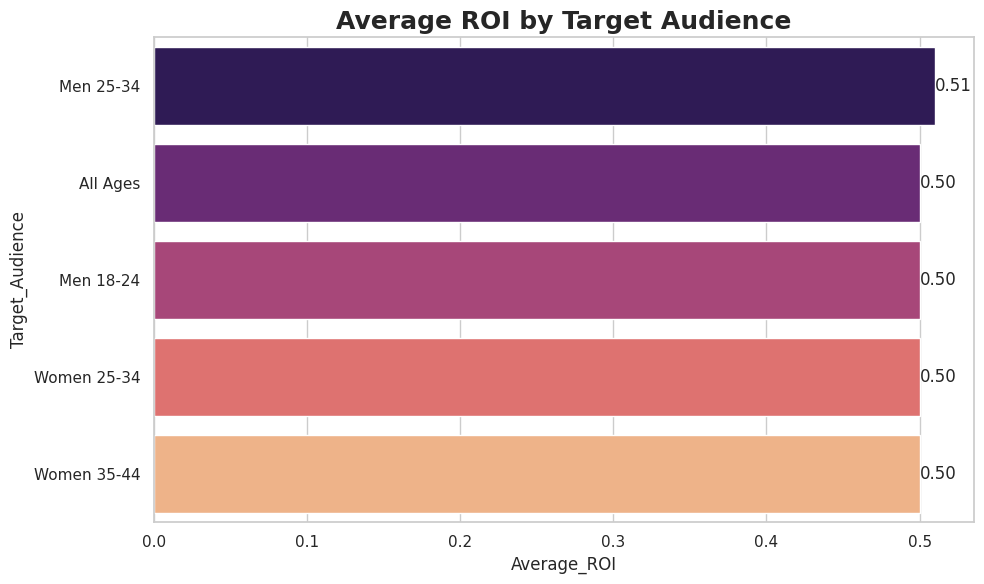

In [27]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=audience_summary.reset_index(),
    x="Average_ROI",
    y="Target_Audience",
    palette="magma"
)

plt.title(
    "Average ROI by Target Audience",
    fontsize=18,
    fontweight="bold"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

# Audience KPI Heatmap

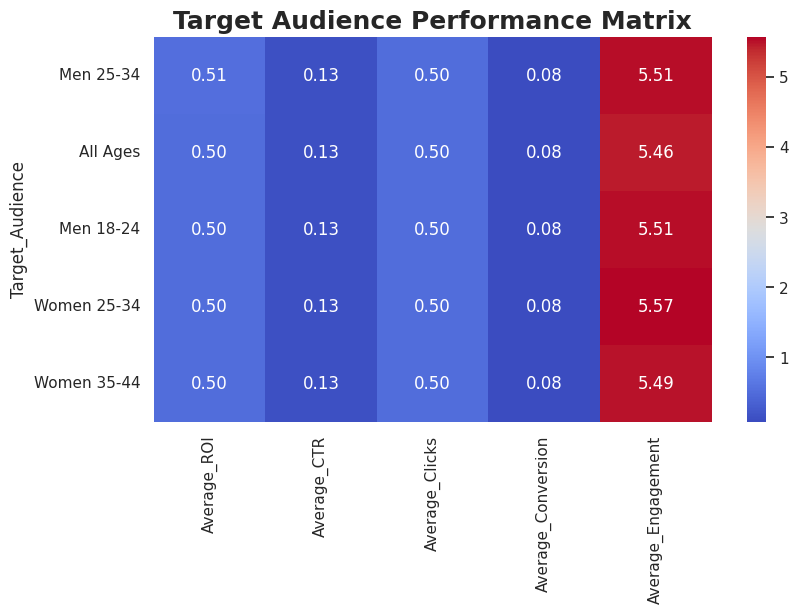

In [28]:
plt.figure(figsize=(9,5))

sns.heatmap(
    audience_summary,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Target Audience Performance Matrix",
    fontsize=18,
    fontweight="bold"
)

plt.show()

# Customer Segment Analysis

# Customer Segment KPI

In [29]:
segment_summary = (
    df.groupby("Customer_Segment")
      .agg(
          Average_ROI=("ROI","mean"),
          Average_CTR=("CTR","mean"),
          Average_Clicks=("Clicks","mean"),
          Average_Conversion=("Conversion_Rate","mean"),
          Average_Engagement=("Engagement_Score","mean")
      )
      .round(2)
      .sort_values("Average_ROI", ascending=False)
)

segment_summary

,Average_ROI,Average_CTR,Average_Clicks,Average_Conversion,Average_Engagement
Customer_Segment,,,,,
Foodies,0.51,0.13,0.50,0.08,5.53
Fashionistas,0.50,0.13,0.50,0.08,5.54
Health & Wellness,0.50,0.13,0.50,0.08,5.45
Outdoor Adventurers,0.50,0.13,0.50,0.08,5.51
Tech Enthusiasts,0.50,0.13,0.49,0.08,5.50


# ROI by Customer Segment

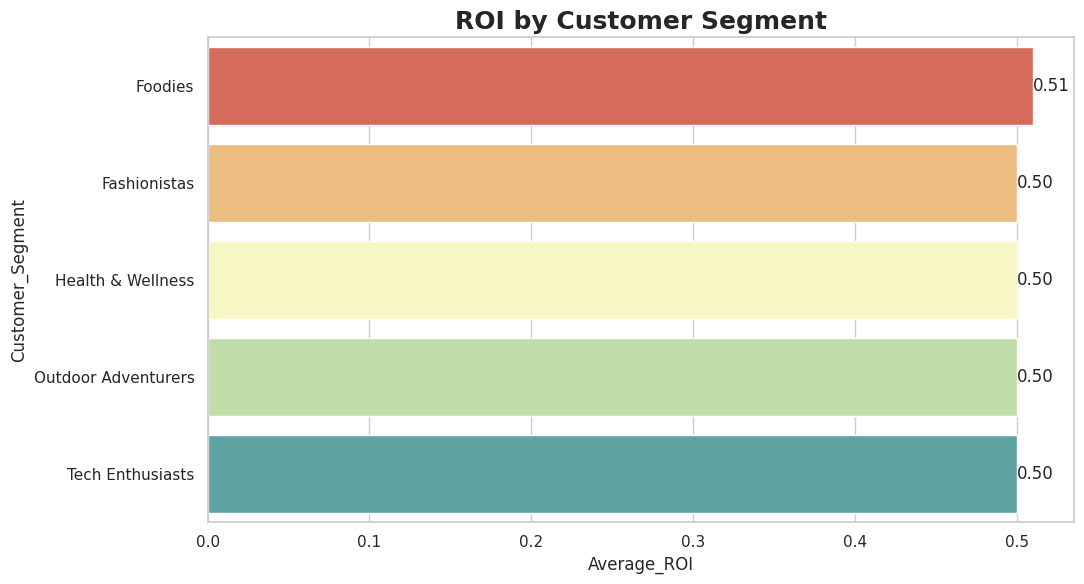

In [30]:
plt.figure(figsize=(11,6))

ax = sns.barplot(
    data=segment_summary.reset_index(),
    x="Average_ROI",
    y="Customer_Segment",
    palette="Spectral"
)

plt.title(
    "ROI by Customer Segment",
    fontsize=18,
    fontweight="bold"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

# Customer Segment Heatmap

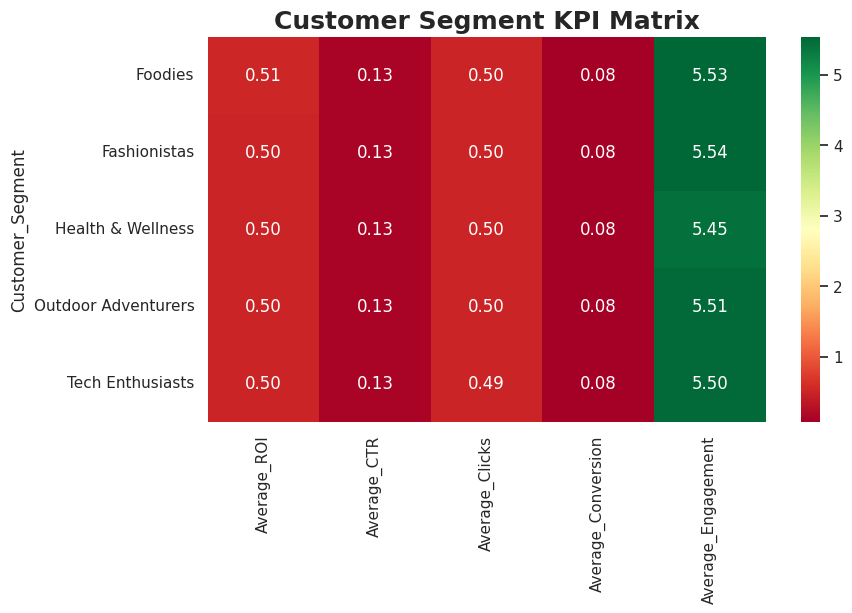

In [31]:
plt.figure(figsize=(9,5))

sns.heatmap(
    segment_summary,
    annot=True,
    cmap="RdYlGn",
    fmt=".2f"
)

plt.title(
    "Customer Segment KPI Matrix",
    fontsize=18,
    fontweight="bold"
)

plt.show()

# Language Analysis

# Language KPI Summary

In [32]:
language_summary = (
    df.groupby("Language")
      .agg(
          Average_ROI=("ROI","mean"),
          Average_CTR=("CTR","mean"),
          Average_Clicks=("Clicks","mean"),
          Average_Conversion=("Conversion_Rate","mean"),
          Average_Engagement=("Engagement_Score","mean")
      )
      .round(2)
      .sort_values("Average_ROI", ascending=False)
)

language_summary

,Average_ROI,Average_CTR,Average_Clicks,Average_Conversion,Average_Engagement
Language,,,,,
English,0.50,0.13,0.50,0.08,5.52
French,0.50,0.13,0.50,0.08,5.47
German,0.50,0.13,0.49,0.08,5.52
Spanish,0.50,0.14,0.50,0.08,5.44
Mandarin,0.49,0.13,0.50,0.08,5.58


# ROI by Language

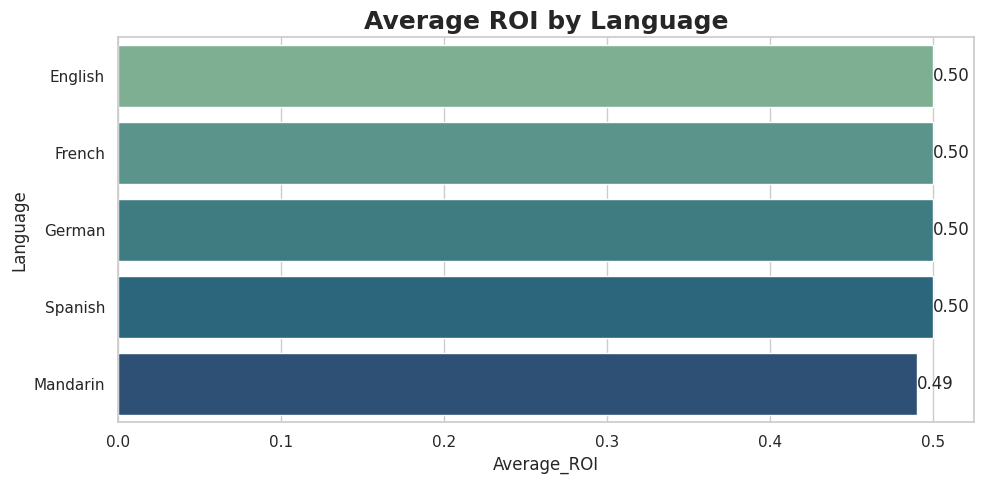

In [33]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=language_summary.reset_index(),
    x="Average_ROI",
    y="Language",
    palette="crest"
)

plt.title(
    "Average ROI by Language",
    fontsize=18,
    fontweight="bold"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

# Location Analysis

# Location KPI Summary

In [34]:
location_summary = (
    df.groupby("Location")
      .agg(
          Average_ROI=("ROI","mean"),
          Average_CTR=("CTR","mean"),
          Average_Clicks=("Clicks","mean"),
          Average_Conversion=("Conversion_Rate","mean"),
          Average_Engagement=("Engagement_Score","mean")
      )
      .round(2)
      .sort_values("Average_ROI", ascending=False)
)

location_summary

,Average_ROI,Average_CTR,Average_Clicks,Average_Conversion,Average_Engagement
Location,,,,,
Chicago,0.5,0.13,0.50,0.08,5.50
Houston,0.5,0.13,0.50,0.08,5.52
Los Angeles,0.5,0.13,0.50,0.08,5.58
Miami,0.5,0.13,0.49,0.08,5.45
New York,0.5,0.13,0.50,0.08,5.48


# Top Performing Locations

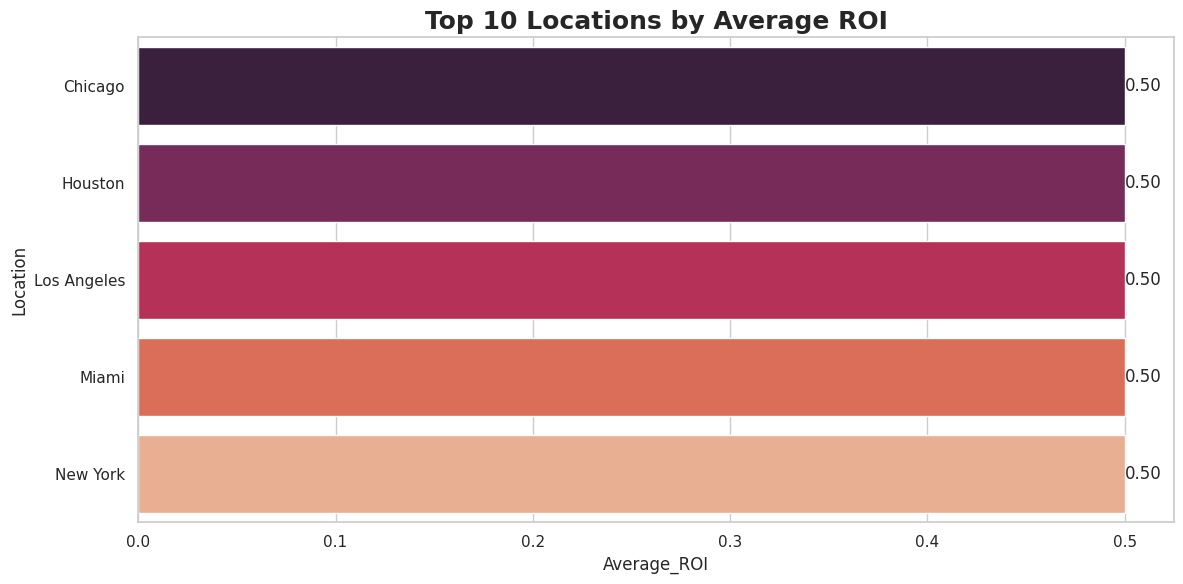

In [35]:
top_locations = location_summary.head(10).reset_index()

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_locations,
    x="Average_ROI",
    y="Location",
    palette="rocket"
)

plt.title(
    "Top 10 Locations by Average ROI",
    fontsize=18,
    fontweight="bold"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

# Location KPI Heatmap

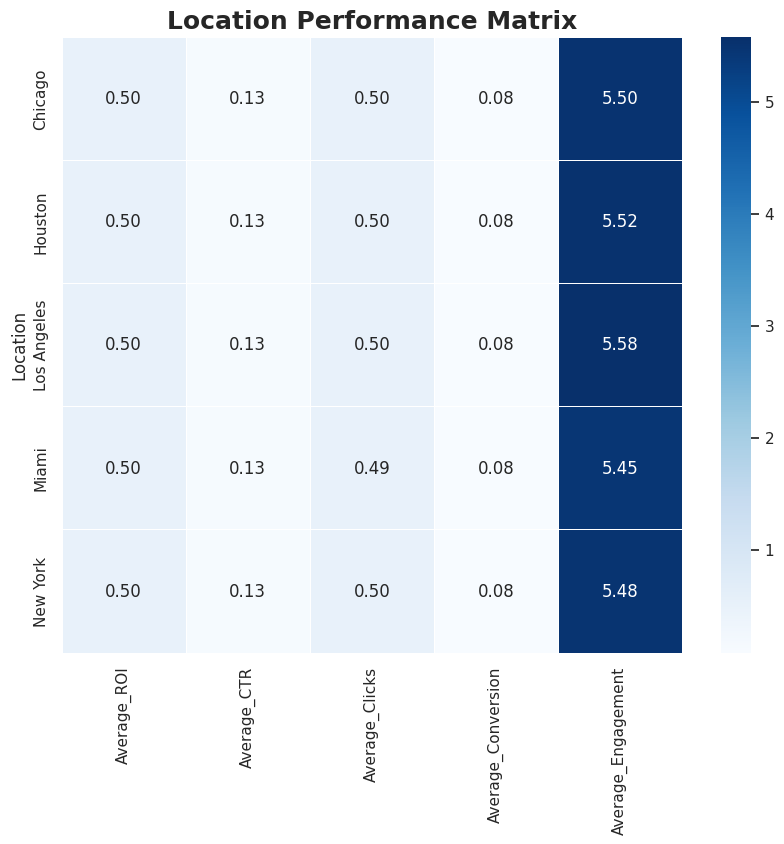

In [36]:
plt.figure(figsize=(10,8))

sns.heatmap(
    location_summary,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=.5
)

plt.title(
    "Location Performance Matrix",
    fontsize=18,
    fontweight="bold"
)

plt.show()

In [37]:
company_summary.to_csv("company_summary.csv")
audience_summary.to_csv("audience_summary.csv")
segment_summary.to_csv("customer_segment_summary.csv")
language_summary.to_csv("language_summary.csv")
location_summary.to_csv("location_summary.csv")

print("✅ Summary tables exported successfully.")

✅ Summary tables exported successfully.
